# 📊 Spotify Customer Churn - Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlepad'] = 15

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


In [ ]:
# Read dataset safely from the project root directory
df = pd.read_csv('/content/spotify_churn_dataset.csv')

In [ ]:
print('🎵 Spotify Dataset Loaded Successfully!')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print('='*50)
print(f'Memory Usage: {df.memory_usage(deep=True).sum()/1024:.2f} KB')


🎵 Spotify Dataset Loaded Successfully!
Dataset Shape: 8000 rows, 12 columns
Memory Usage: 2174.85 KB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


In [ ]:
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [ ]:
df.tail()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0
7999,8000,Other,45,AU,Free,210,68,0.46,Desktop,6,0,0


In [ ]:
df.shape

(8000, 12)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,8000.00,4000.50,2309.55,1.00,2000.75,4000.50,6000.25,8000.00
age,8000.00,37.66,12.74,16.00,26.00,38.00,49.00,59.00
listening_time,8000.00,154.07,84.02,10.00,81.00,154.00,227.00,299.00
songs_played_per_day,8000.00,50.13,28.45,1.00,25.00,50.00,75.00,99.00
skip_rate,8000.00,0.30,0.17,0.00,0.15,0.30,0.45,0.60
ads_listened_per_week,8000.00,6.94,13.62,0.00,0.00,0.00,5.00,49.00
offline_listening,8000.00,0.75,0.43,0.00,0.00,1.00,1.00,1.00
is_churned,8000.00,0.26,0.44,0.00,0.00,0.00,1.00,1.00


### Sayısal Değişkenler Detaylı İstatistikler

In [ ]:
spotify_sayisal=['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week']

print('='*70)
for kolon in spotify_sayisal :
  veri=df[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)


 * AGE
Ortalama: 37.66
Medyan: 38.00
Standart Sapma: 12.74
Minimum: 16.00
Maksimum: 59.00
Varyans: 162.32
Skewness(Çarpıklık): -0.03
Kurtosis(Basıklık): -1.21
IQR: 23.00

 * LISTENING_TIME
Ortalama: 154.07
Medyan: 154.00
Standart Sapma: 84.02
Minimum: 10.00
Maksimum: 299.00
Varyans: 7058.62
Skewness(Çarpıklık): 0.01
Kurtosis(Basıklık): -1.21
IQR: 146.00

 * SONGS_PLAYED_PER_DAY
Ortalama: 50.13
Medyan: 50.00
Standart Sapma: 28.45
Minimum: 1.00
Maksimum: 99.00
Varyans: 809.39
Skewness(Çarpıklık): -0.00
Kurtosis(Basıklık): -1.19
IQR: 50.00

 * SKIP_RATE
Ortalama: 0.30
Medyan: 0.30
Standart Sapma: 0.17
Minimum: 0.00
Maksimum: 0.60
Varyans: 0.03
Skewness(Çarpıklık): 0.01
Kurtosis(Basıklık): -1.19
IQR: 0.30

 * ADS_LISTENED_PER_WEEK
Ortalama: 6.94
Medyan: 0.00
Standart Sapma: 13.62
Minimum: 0.00
Maksimum: 49.00
Varyans: 185.45
Skewness(Çarpıklık): 1.80
Kurtosis(Basıklık): 1.81
IQR: 5.00


In [ ]:
df.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


In [ ]:
df.describe(include=['object','category']).T

,count,unique,top,freq
gender,8000,3,Male,2691
country,8000,8,AU,1034
subscription_type,8000,4,Premium,2115
device_type,8000,3,Desktop,2778


<Axes: xlabel='is_churned', ylabel='count'>

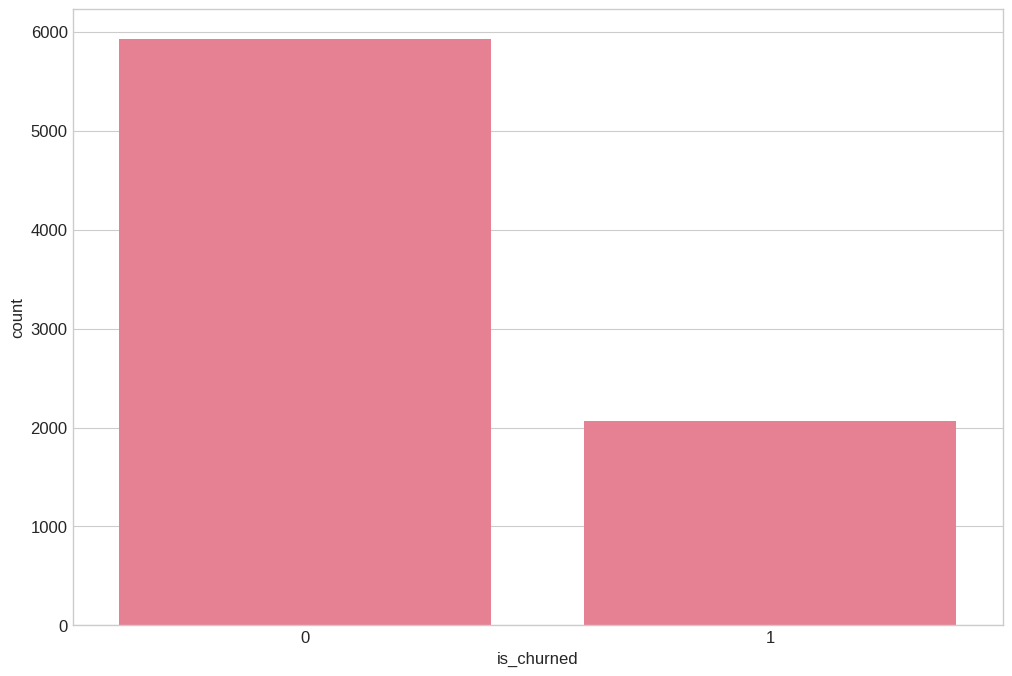

In [ ]:
sns.countplot(data=df, x='is_churned')

In [ ]:
spotify_sayisal=['age','listening_time','songs_played_per_day','skip_rate','ads_listened_per_week']

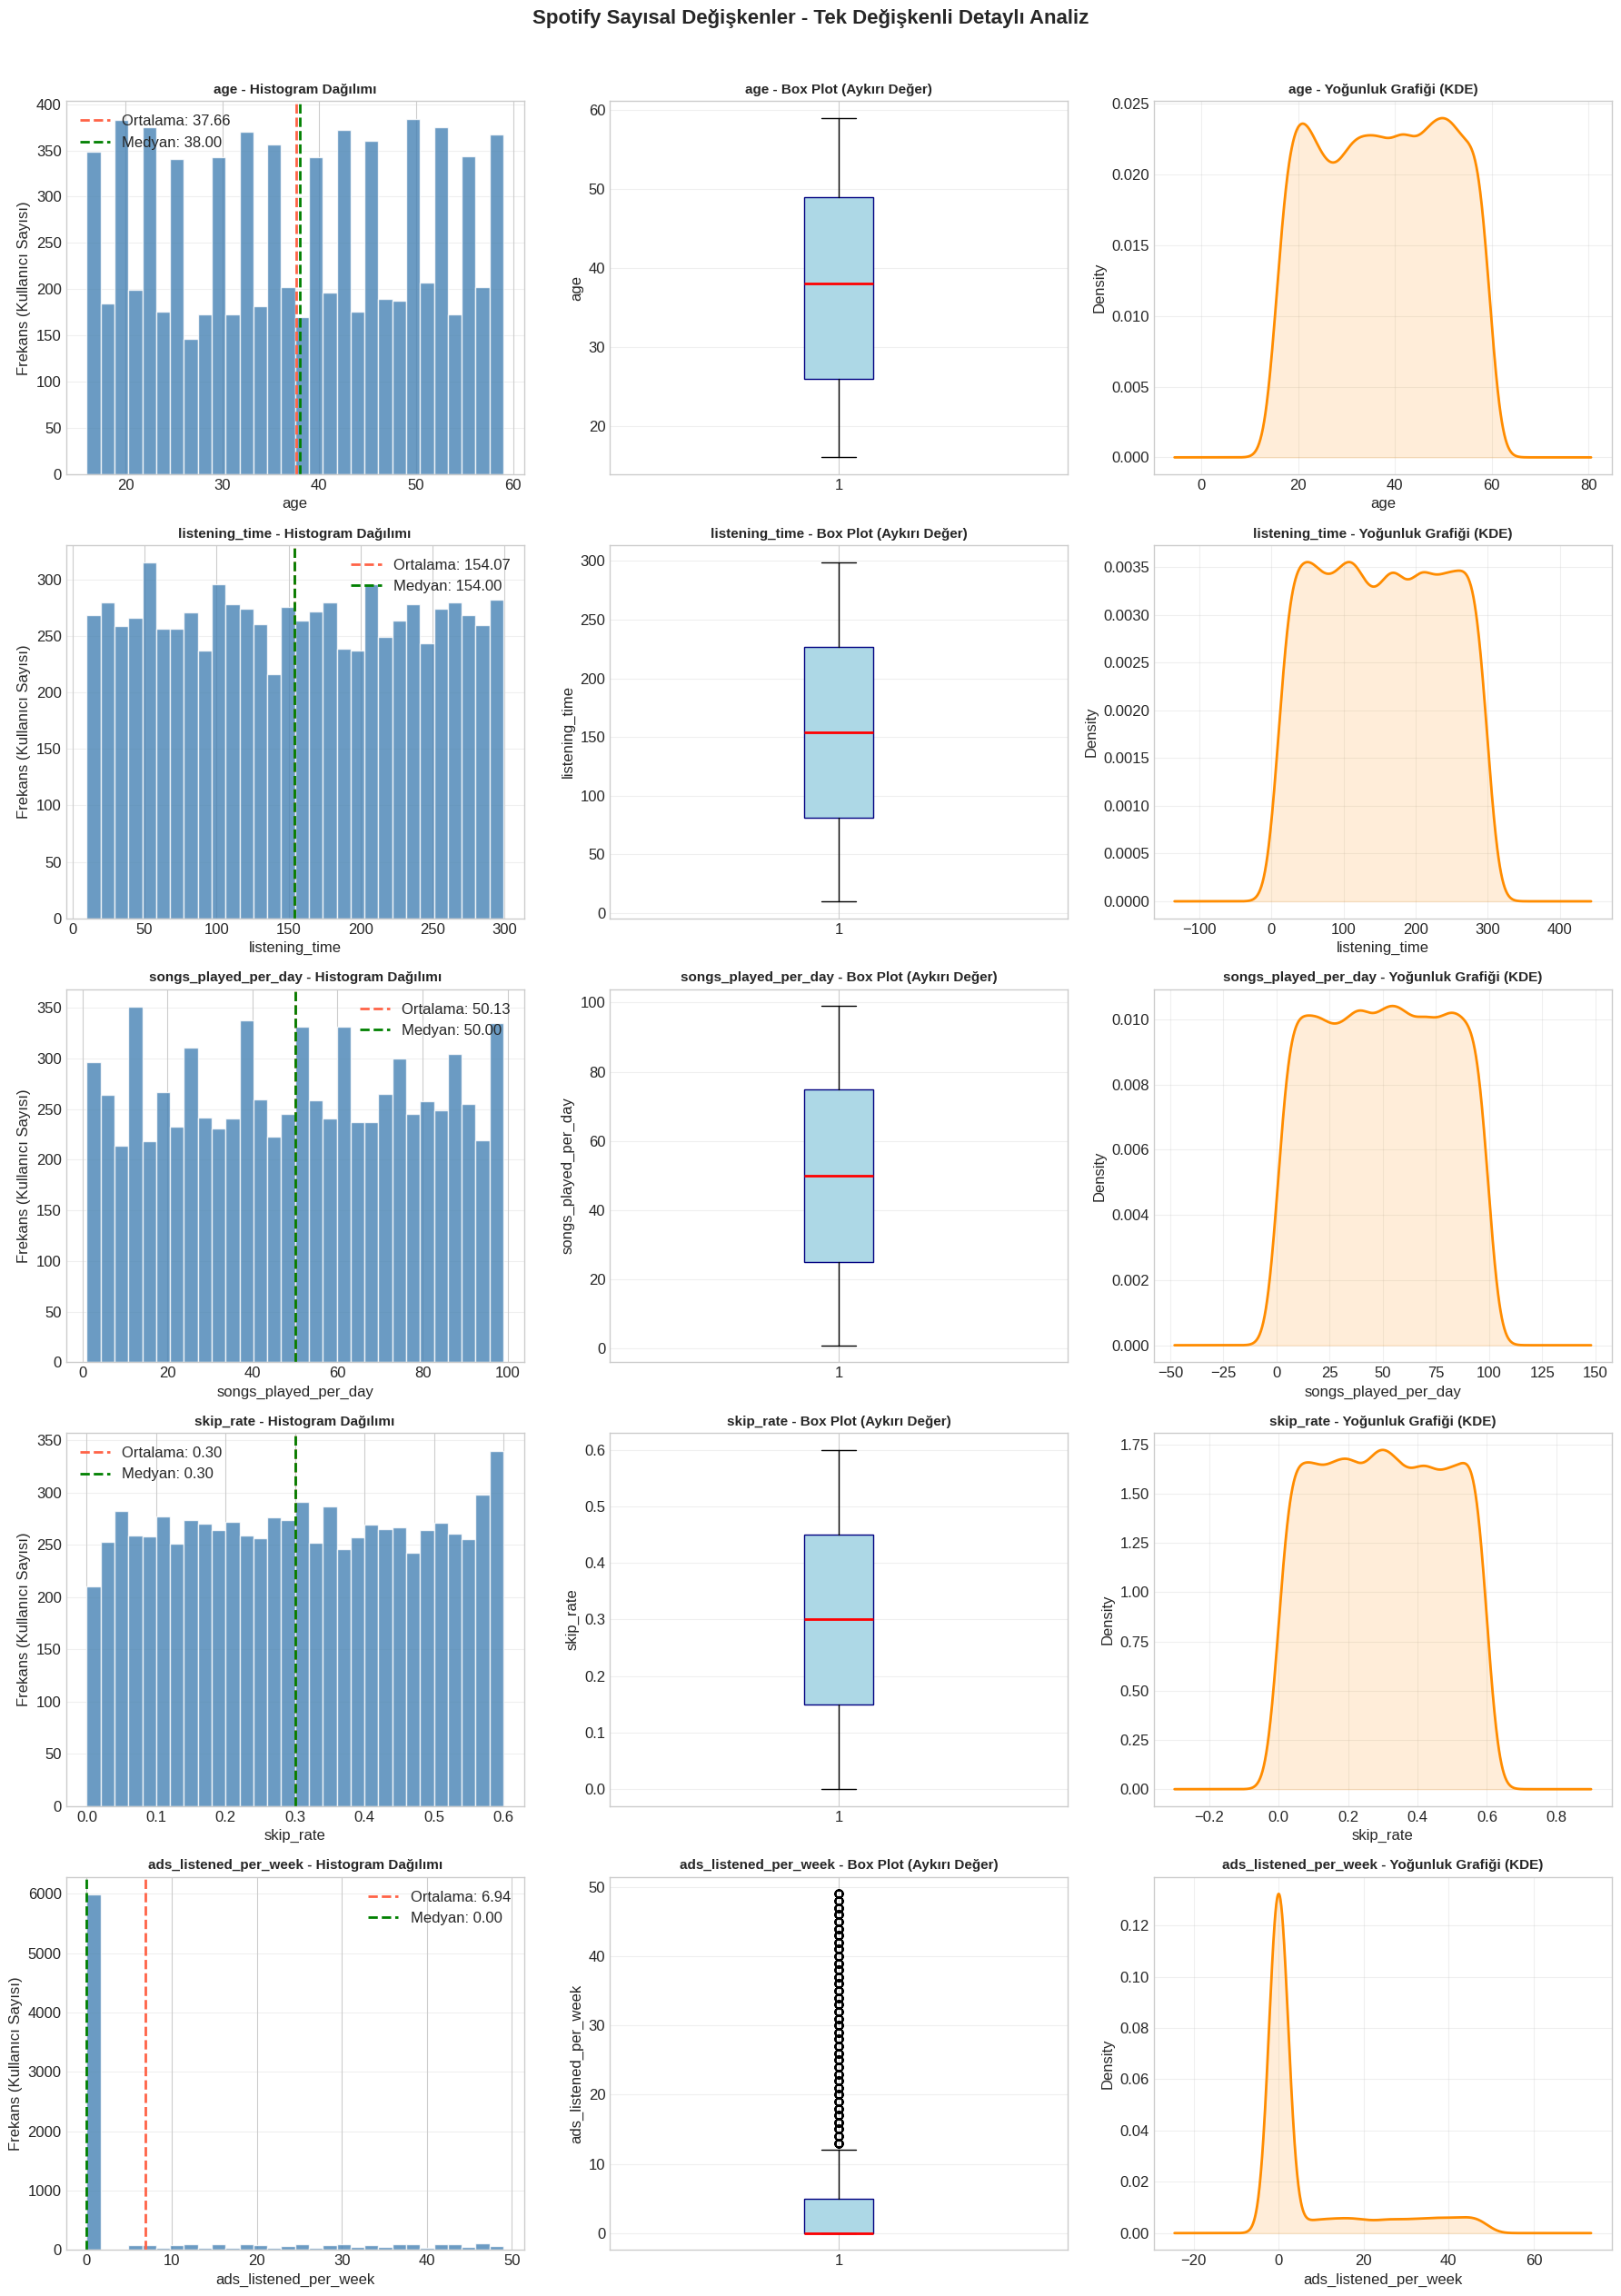

In [ ]:
fig, axes = plt.subplots(len(spotify_sayisal), 3, figsize=(18, 5 * len(spotify_sayisal)))

for i, kolon in enumerate(spotify_sayisal):
    # Boş verileri temizleyip seriyi alıyoruz
    veri = df[kolon].dropna()

    # --- 1. GRAFİK: HISTOGRAM ---
    axes[i, 0].hist(veri, bins=30, color="steelblue", edgecolor='white', alpha=0.8)
    axes[i, 0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama: {veri.mean():.2f}')
    axes[i, 0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan: {veri.median():.2f}')
    axes[i, 0].set_title(f'{kolon} - Histogram Dağılımı', fontsize=11, fontweight='bold')
    axes[i, 0].set_xlabel(kolon)
    axes[i, 0].set_ylabel('Frekans (Kullanıcı Sayısı)')
    axes[i, 0].legend()
    axes[i, 0].grid(axis='y', alpha=0.3)

    # --- 2. GRAFİK: BOX PLOT (Aykırı Değer Analizi) ---
    axes[i, 1].boxplot(veri, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'{kolon} - Box Plot (Aykırı Değer)', fontsize=11, fontweight='bold')
    axes[i, 1].set_ylabel(kolon)
    axes[i, 1].grid(axis='y', alpha=0.3)

    # --- 3. GRAFİK: KDE (Yoğunluk Grafiği) ---
    veri.plot.kde(ax=axes[i, 2], color='darkorange', linewidth=2)
    # Çizginin altını boyayarak estetik katıyoruz
    line = axes[i, 2].lines[0]
    axes[i, 2].fill_between(line.get_xdata(), line.get_ydata(), color='darkorange', alpha=0.15)
    axes[i, 2].set_title(f'{kolon} - Yoğunluk Grafiği (KDE)', fontsize=11, fontweight='bold')
    axes[i, 2].set_xlabel(kolon)
    axes[i, 2].grid(True, alpha=0.3)

# Genel Grafik Başlığı
plt.suptitle('Spotify Sayısal Değişkenler - Tek Değişkenli Detaylı Analiz', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
print('Sayısal Değişkenler detaylı İstatistikler:')
print('='*70)


Sayısal Değişkenler detaylı İstatistikler:


In [ ]:
for kolon in spotify_sayisal :
  veri=df[kolon].dropna()
  print(f'\n * {kolon.upper()}')
  print(f'Ortalama: {veri.mean():.2f}')
  print(f'Medyan: {veri.median():.2f}')
  print(f'Standart Sapma: {veri.std():.2f}')
  print(f'Minimum: {veri.min():.2f}')
  print(f'Maksimum: {veri.max():.2f}')
  print(f'Varyans: {veri.var():.2f}')
  print(f'Skewness(Çarpıklık): {veri.skew():.2f}')
  print(f'Kurtosis(Basıklık): {veri.kurtosis():.2f}')
  print(f'IQR: {veri.quantile(0.75)-veri.quantile(0.25):.2f}')
  print('='*70)


 * AGE
Ortalama: 37.66
Medyan: 38.00
Standart Sapma: 12.74
Minimum: 16.00
Maksimum: 59.00
Varyans: 162.32
Skewness(Çarpıklık): -0.03
Kurtosis(Basıklık): -1.21
IQR: 23.00

 * LISTENING_TIME
Ortalama: 154.07
Medyan: 154.00
Standart Sapma: 84.02
Minimum: 10.00
Maksimum: 299.00
Varyans: 7058.62
Skewness(Çarpıklık): 0.01
Kurtosis(Basıklık): -1.21
IQR: 146.00

 * SONGS_PLAYED_PER_DAY
Ortalama: 50.13
Medyan: 50.00
Standart Sapma: 28.45
Minimum: 1.00
Maksimum: 99.00
Varyans: 809.39
Skewness(Çarpıklık): -0.00
Kurtosis(Basıklık): -1.19
IQR: 50.00

 * SKIP_RATE
Ortalama: 0.30
Medyan: 0.30
Standart Sapma: 0.17
Minimum: 0.00
Maksimum: 0.60
Varyans: 0.03
Skewness(Çarpıklık): 0.01
Kurtosis(Basıklık): -1.19
IQR: 0.30

 * ADS_LISTENED_PER_WEEK
Ortalama: 6.94
Medyan: 0.00
Standart Sapma: 13.62
Minimum: 0.00
Maksimum: 49.00
Varyans: 185.45
Skewness(Çarpıklık): 1.80
Kurtosis(Basıklık): 1.81
IQR: 5.00


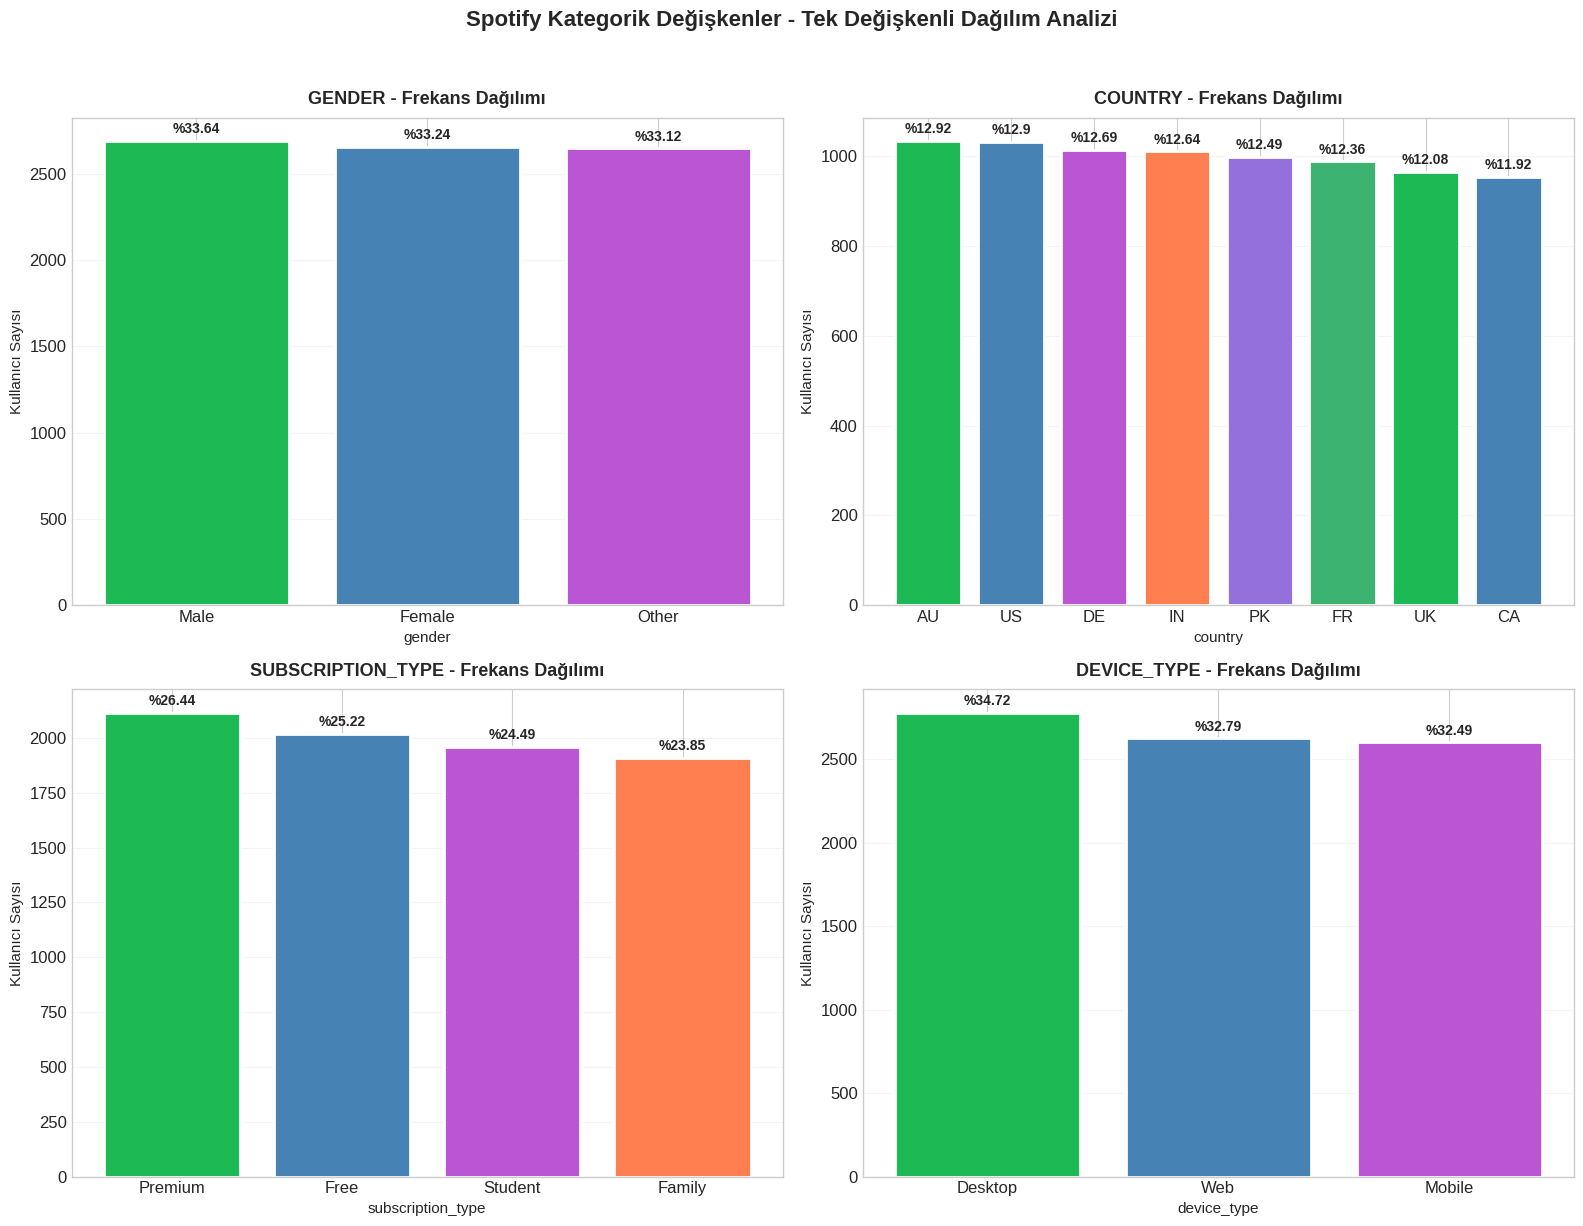

In [ ]:
import matplotlib.pyplot as plt
kategori_kolonlar = ['gender', 'country', 'subscription_type', 'device_type']

# 2x2 boyutunda grafik matrisini kuruyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Estetik ve modern bir renk paleti
renkler = ['#1DB954', '#4682B4', '#BA55D3', '#FF7F50', '#9370DB', '#3CB371']

for i, sutum in enumerate(kategori_kolonlar):
    # Boş verileri temizleyip frekansları alıyoruz
    degerler = df[sutum].dropna().value_counts()
    # Yüzdelik oranları hesaplıyoruz
    yuzde = (degerler / len(df) * 100).round(2)

    # Barları çizdiriyoruz
    bars = axes[i].bar(degerler.index.astype(str), degerler.values,
                       color=renkler[:len(degerler)], edgecolor='white', linewidth=2)

    # Grafik süslemeleri
    axes[i].set_title(f'{sutum.upper()} - Frekans Dağılımı', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel(sutum, fontsize=11)
    axes[i].set_ylabel('Kullanıcı Sayısı', fontsize=11)
    axes[i].grid(axis='y', alpha=0.2)

    # Barların üzerine yüzde değerlerini yazdırma (Hocanın havalı dokunuşu)
    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + (degerler.values.max() * 0.01), # Yazının barın çok az üzerinde durması için
                     f'%{pct}',
                     ha='center',
                     va='bottom',
                     fontsize=10,
                     fontweight='bold')

# Genel Başlık
plt.suptitle('Spotify Kategorik Değişkenler - Tek Değişkenli Dağılım Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

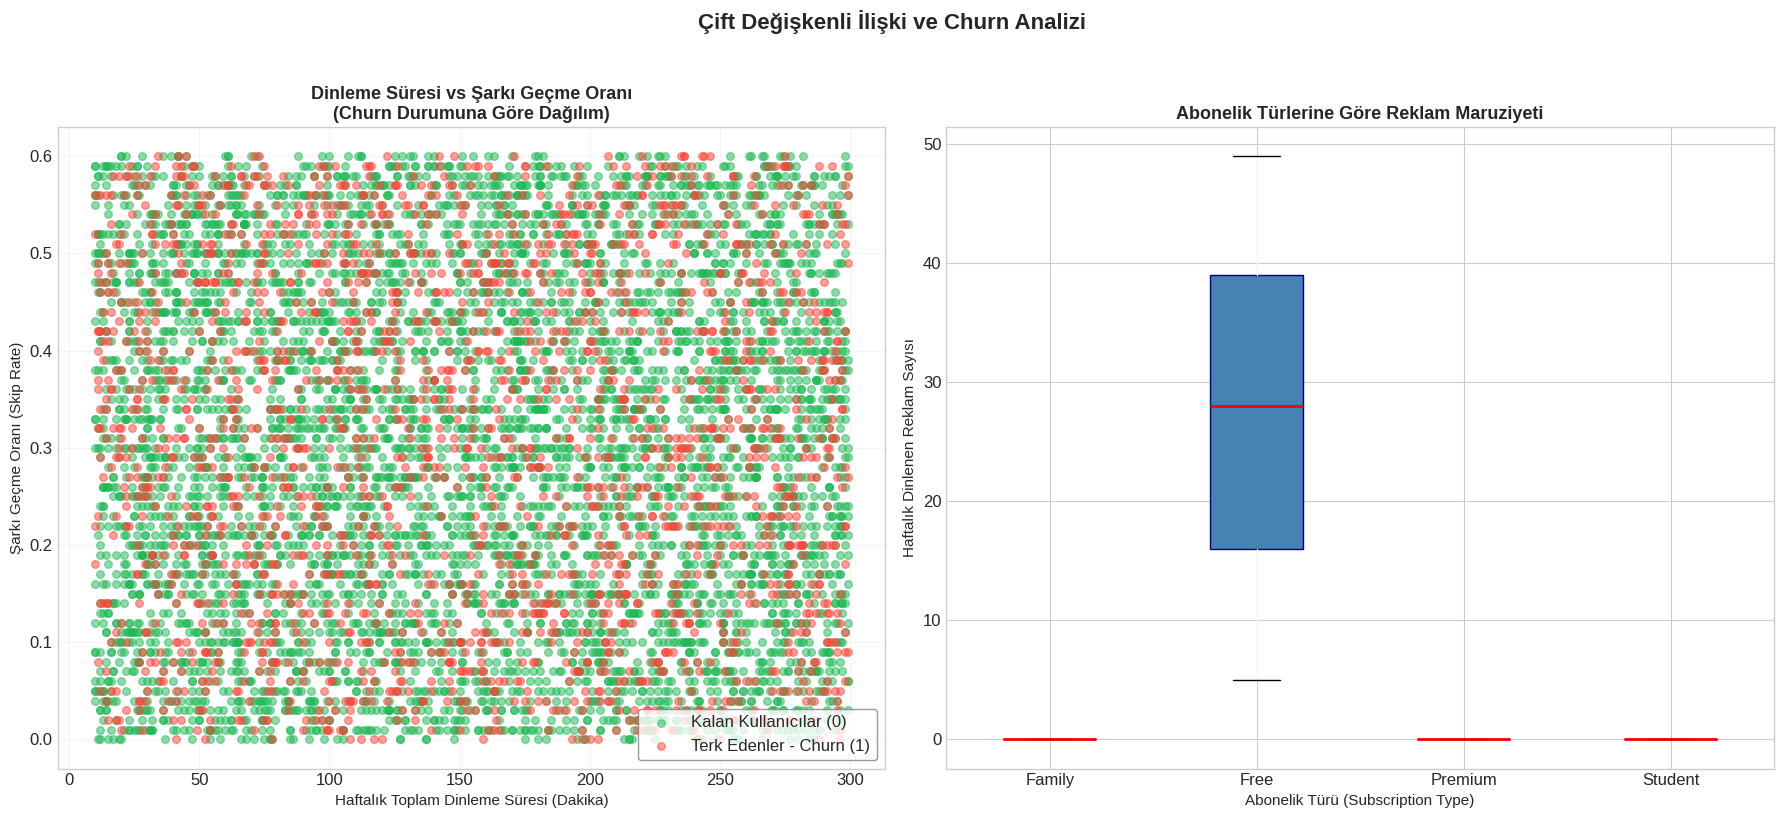

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Veriyi okuyoruz
df = pd.read_csv('spotify_churn_dataset.csv')

# 2. Grafik alt yapısını kuruyoruz (Yan yana 2 grafik)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- 1. GRAFİK: Sayısal vs Sayısal (Scatter Plot) ---
# Churn olan (1) ve kalan (0) kullanıcıları ayırıyoruz
kalanlar = df[df['is_churned'] == 0]
gidenler = df[df['is_churned'] == 1]

# Dinleme süresi ve şarkı geçme oranı ilişkisini çiziyoruz
axes[0].scatter(kalanlar['listening_time'], kalanlar['skip_rate'],
                color='#1DB954', alpha=0.5, label='Kalan Kullanıcılar (0)', s=30)
axes[0].scatter(gidenler['listening_time'], gidenler['skip_rate'],
                color='#FF4136', alpha=0.5, label='Terk Edenler - Churn (1)', s=30)

axes[0].set_xlabel('Haftalık Toplam Dinleme Süresi (Dakika)', fontsize=11)
axes[0].set_ylabel('Şarkı Geçme Oranı (Skip Rate)', fontsize=11)
axes[0].set_title('Dinleme Süresi vs Şarkı Geçme Oranı\n(Churn Durumuna Göre Dağılım)', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True, facecolor='white', edgecolor='gray')
axes[0].grid(True, alpha=0.2)

# --- 2. GRAFİK: Kategorik vs Sayısal (Box Plot) ---
# Abonelik türlerine göre haftalık reklam dinleme sayısını kutu grafiği ile çiziyoruz
# Not: subplots içinde pandas boxplot kullanırken 'ax' parametresini belirtiyoruz
df.boxplot(column='ads_listened_per_week', by='subscription_type', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#4682B4', color='navy'),
           medianprops=dict(color='red', linewidth=2))

axes[1].set_xlabel('Abonelik Türü (Subscription Type)', fontsize=11)
axes[1].set_ylabel('Haftalık Dinlenen Reklam Sayısı', fontsize=11)
axes[1].set_title('Abonelik Türlerine Göre Reklam Maruziyeti', fontsize=13, fontweight='bold')
# Pandas'ın otomatik ürettiği gereksiz alt başlığı temizliyoruz
plt.suptitle('', y=1.0)

# Genel Üst Başlık
fig.suptitle('Çift Değişkenli İlişki ve Churn Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

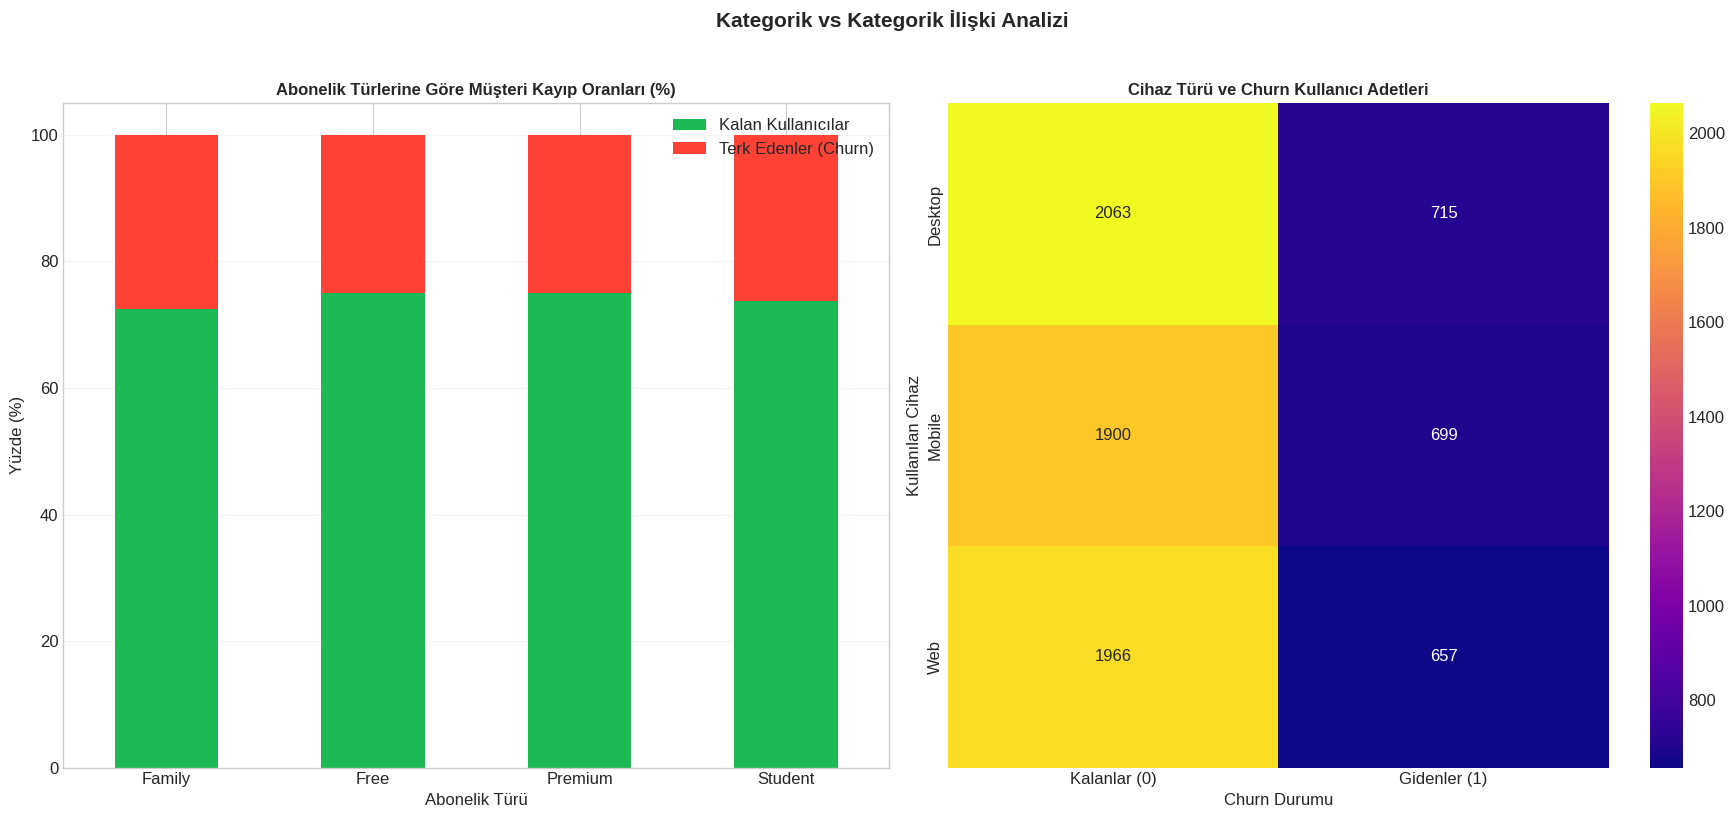

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi okuyoruz
df = pd.read_csv('spotify_churn_dataset.csv')

# --- 1. KOD BLOĞU UYARLAMASI ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Sol Grafik: Abonelik Türü ve Churn Yüzdesi (Stacked Bar)
ct_pct = pd.crosstab(df['subscription_type'], df['is_churned'], normalize='index') * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#1DB954', '#FF4136'])

axes[0].set_title('Abonelik Türlerine Göre Müşteri Kayıp Oranları (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Abonelik Türü')
axes[0].set_ylabel('Yüzde (%)')
axes[0].legend(['Kalan Kullanıcılar', 'Terk Edenler (Churn)'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.2)

# Sağ Grafik: Cihaz Türü ve Churn Sayıları (Heatmap)
ct2 = pd.crosstab(df['device_type'], df['is_churned'])
ct2.columns = ['Kalanlar (0)', 'Gidenler (1)']

sns.heatmap(ct2, annot=True, fmt='d', cmap='plasma', ax=axes[1])
axes[1].set_title('Cihaz Türü ve Churn Kullanıcı Adetleri', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn Durumu')
axes[1].set_ylabel('Kullanılan Cihaz')

plt.suptitle('Kategorik vs Kategorik İlişki Analizi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

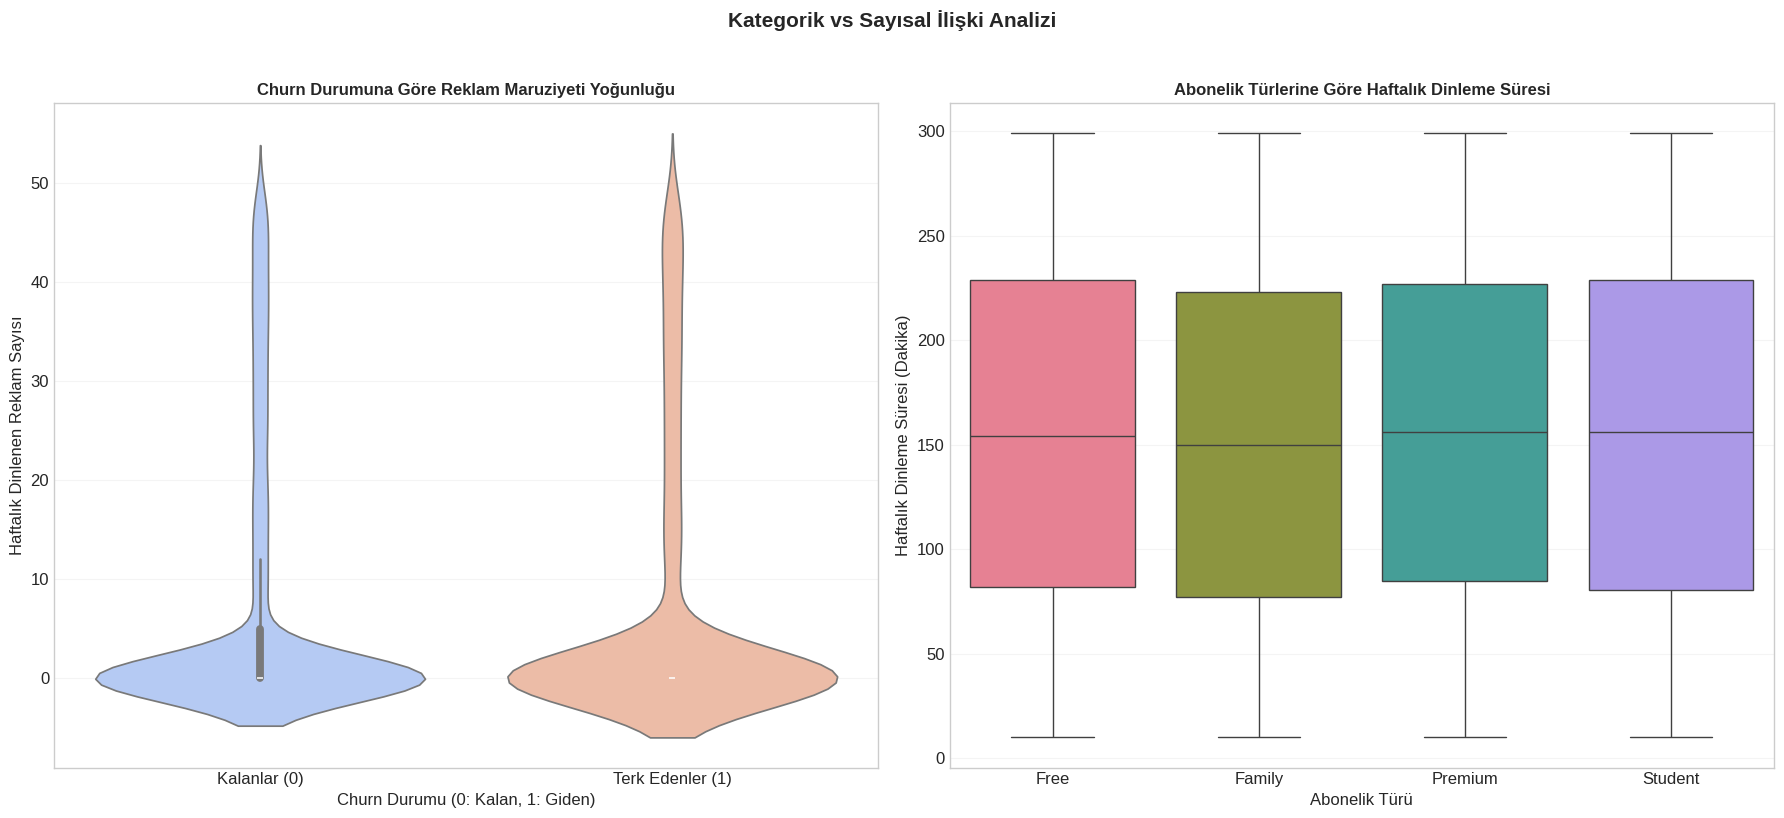

In [ ]:
# --- 2. KOD BLOĞU UYARLAMASI ---
# 2x1'lik bir matris kuralım (Yan yana daha şık duracaktır)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Sol Grafik: Churn Durumuna Göre Reklam Dağılımı (Violin Plot)
sns.violinplot(data=df, x='is_churned', y='ads_listened_per_week', ax=axes[0], palette='coolwarm')
axes[0].set_title('Churn Durumuna Göre Reklam Maruziyeti Yoğunluğu', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Churn Durumu (0: Kalan, 1: Giden)')
axes[0].set_ylabel('Haftalık Dinlenen Reklam Sayısı')
axes[0].set_xticklabels(['Kalanlar (0)', 'Terk Edenler (1)'])
axes[0].grid(axis='y', alpha=0.2)

# Sağ Grafik: Abonelik Türüne Göre Dinleme Süresi (Box Plot)
sns.boxplot(data=df, x='subscription_type', y='listening_time', ax=axes[1], palette='husl')
axes[1].set_title('Abonelik Türlerine Göre Haftalık Dinleme Süresi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Abonelik Türü')
axes[1].set_ylabel('Haftalık Dinleme Süresi (Dakika)')
axes[1].grid(axis='y', alpha=0.2)

plt.suptitle('Kategorik vs Sayısal İlişki Analizi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

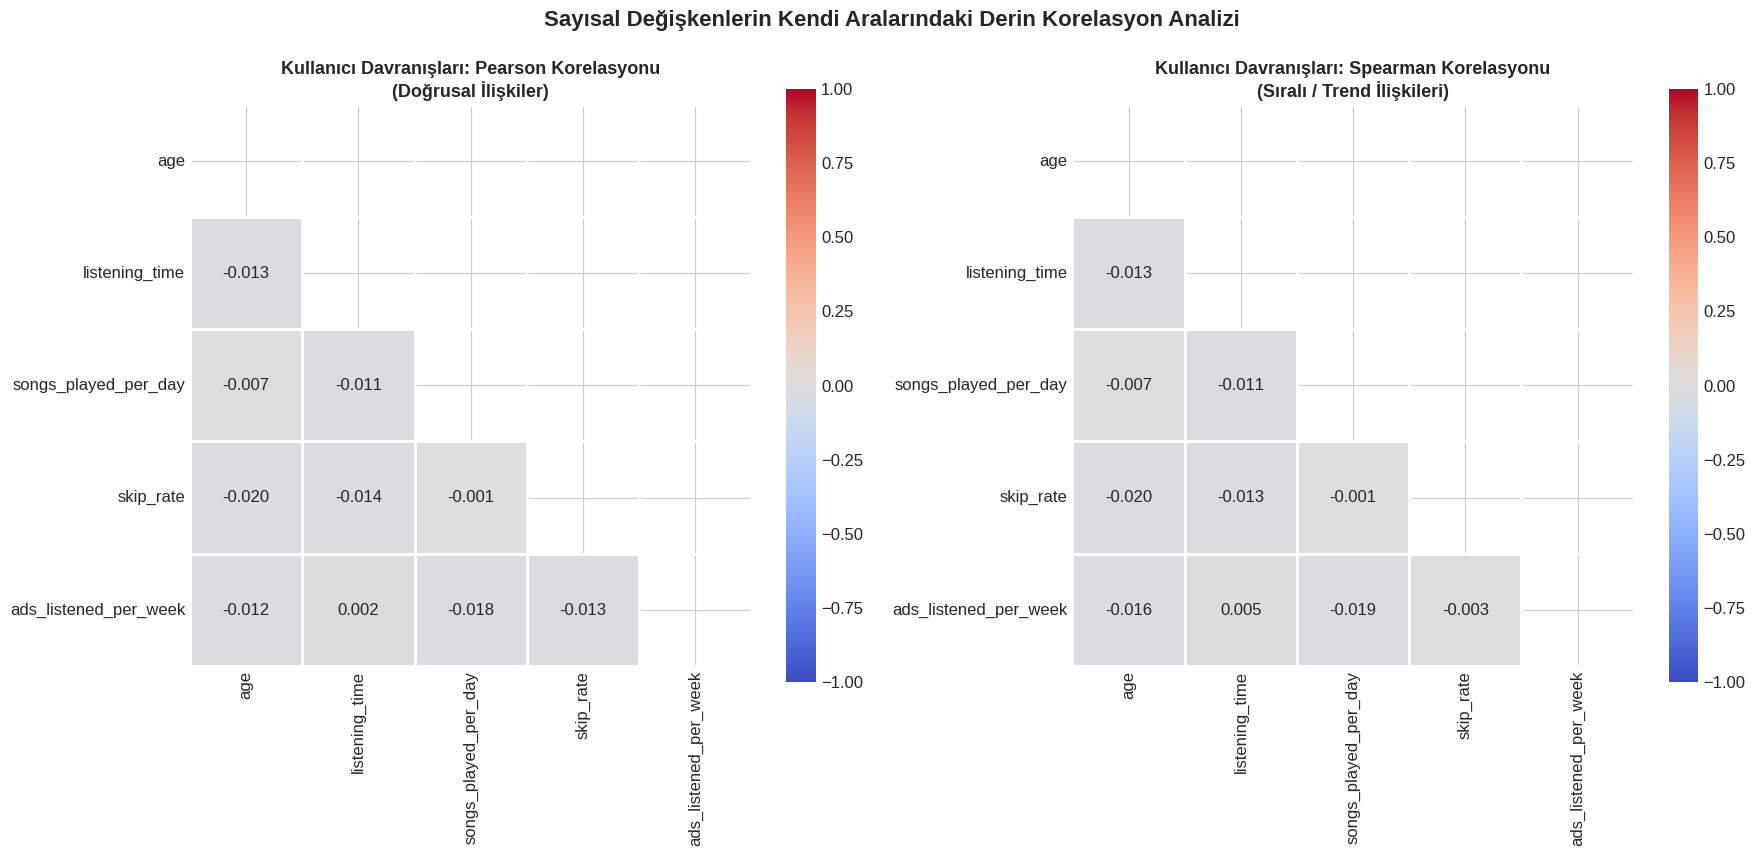

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi okuyoruz
df = pd.read_csv('spotify_churn_dataset.csv')

# Sadece saf ve sürekli sayısal değişkenleri seçiyoruz (is_churned YOK)
saf_sayisal = df[['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Matrisin üst kısmını kapatmak için mask (Görsel temizlik)
mask = np.triu(np.ones_like(saf_sayisal.corr(), dtype=bool))

# --- A. Pearson Korelasyon Matrisi ---
pearson_corr = saf_sayisal.corr(method='pearson')
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Kullanıcı Davranışları: Pearson Korelasyonu\n(Doğrusal İlişkiler)', fontsize=13, fontweight='bold')

# --- B. Spearman Korelasyon Matrisi ---
spearman_corr = saf_sayisal.corr(method='spearman')
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Kullanıcı Davranışları: Spearman Korelasyonu\n(Sıralı / Trend İlişkileri)', fontsize=13, fontweight='bold')

plt.suptitle('Sayısal Değişkenlerin Kendi Aralarındaki Derin Korelasyon Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# Tüm sayısal değişkenlerin birbirleriyle olan ilişkisini scatter plot matrisi olarak çizdirme
# Projeye inanılmaz profesyonel bir hava katar


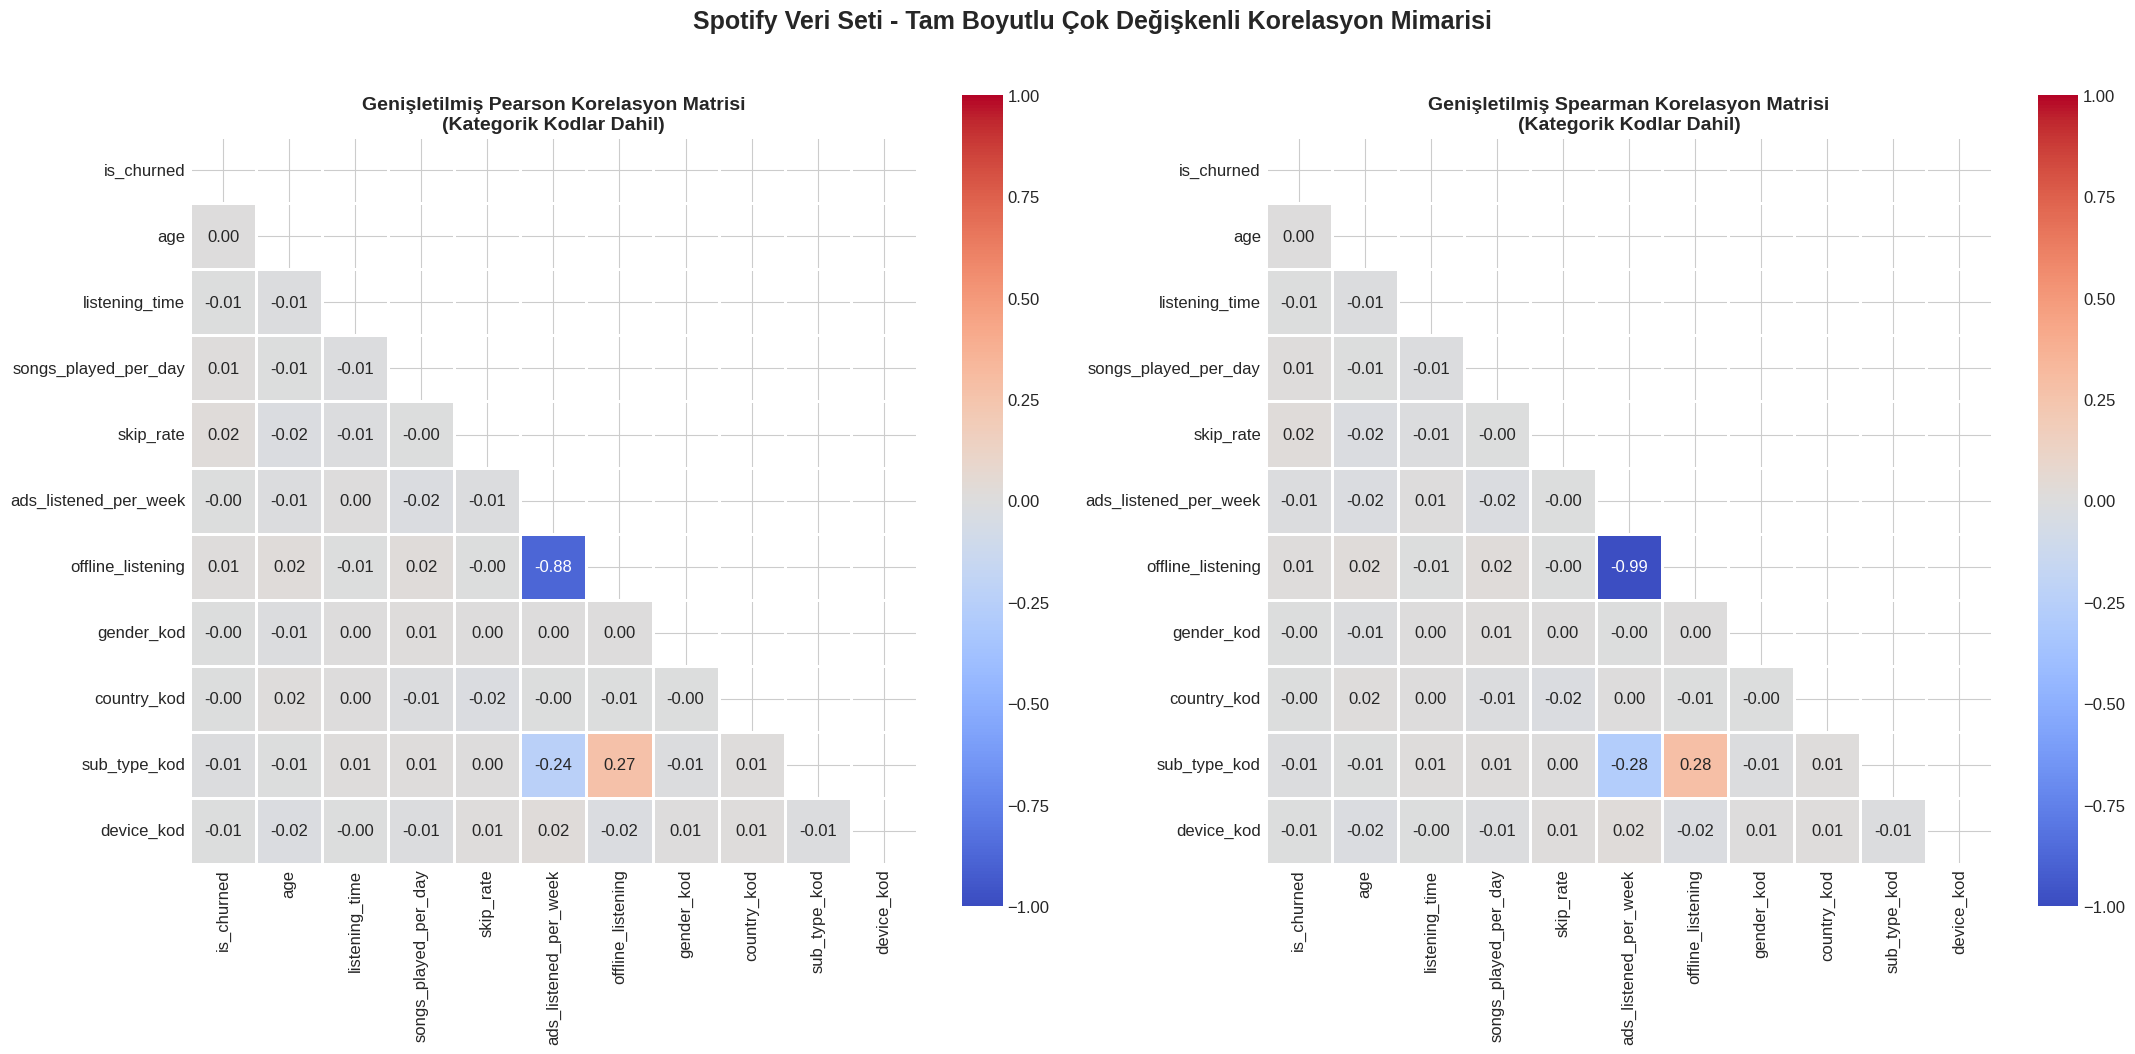

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Veriyi okuyoruz
df = pd.read_csv('spotify_churn_dataset.csv')

# 2. GÖZDEN KAÇAN KATEGORİK SÜTUNLARI SAYISAL KODLARA DÖNÜŞTÜRÜYORUZ (Hocanın Seviyesi)
df_analiz = df.copy()

# .astype('category').cat.codes ifadesi metinleri (Örn: Premium->0, Free->1, Student->2) yapar
df_analiz['gender_kod'] = df_analiz['gender'].astype('category').cat.codes
df_analiz['country_kod'] = df_analiz['country'].astype('category').cat.codes
df_analiz['sub_type_kod'] = df_analiz['subscription_type'].astype('category').cat.codes
df_analiz['device_kod'] = df_analiz['device_type'].astype('category').cat.codes

# 3. ŞİMDİ TÜM DEĞİŞKENLERİ BİR ARAYA TOPLUYORUZ (İşte Gerçek Çok Değişkenli Matris!)
genis_sutunlar = [
    'is_churned', 'age', 'listening_time', 'songs_played_per_day',
    'skip_rate', 'ads_listened_per_week', 'offline_listening',
    'gender_kod', 'country_kod', 'sub_type_kod', 'device_kod'
]

genis_df = df_analiz[genis_sutunlar]

# Grafik alt yapısı (Pearson ve Spearman yan yana)
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
mask = np.triu(np.ones_like(genis_df.corr(), dtype=bool))

# --- A. GENİŞTİRİLMİŞ PEARSON MATRİSİ ---
pearson_genis = genis_df.corr(method='pearson')
sns.heatmap(pearson_genis, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.8, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Genişletilmiş Pearson Korelasyon Matrisi\n(Kategorik Kodlar Dahil)', fontsize=14, fontweight='bold')

# --- B. GENİŞTİRİLMİŞ SPEARMAN MATRİSİ ---
spearman_genis = genis_df.corr(method='spearman')
sns.heatmap(spearman_genis, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.8, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Genişletilmiş Spearman Korelasyon Matrisi\n(Kategorik Kodlar Dahil)', fontsize=14, fontweight='bold')

plt.suptitle('Spotify Veri Seti - Tam Boyutlu Çok Değişkenli Korelasyon Mimarisi', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

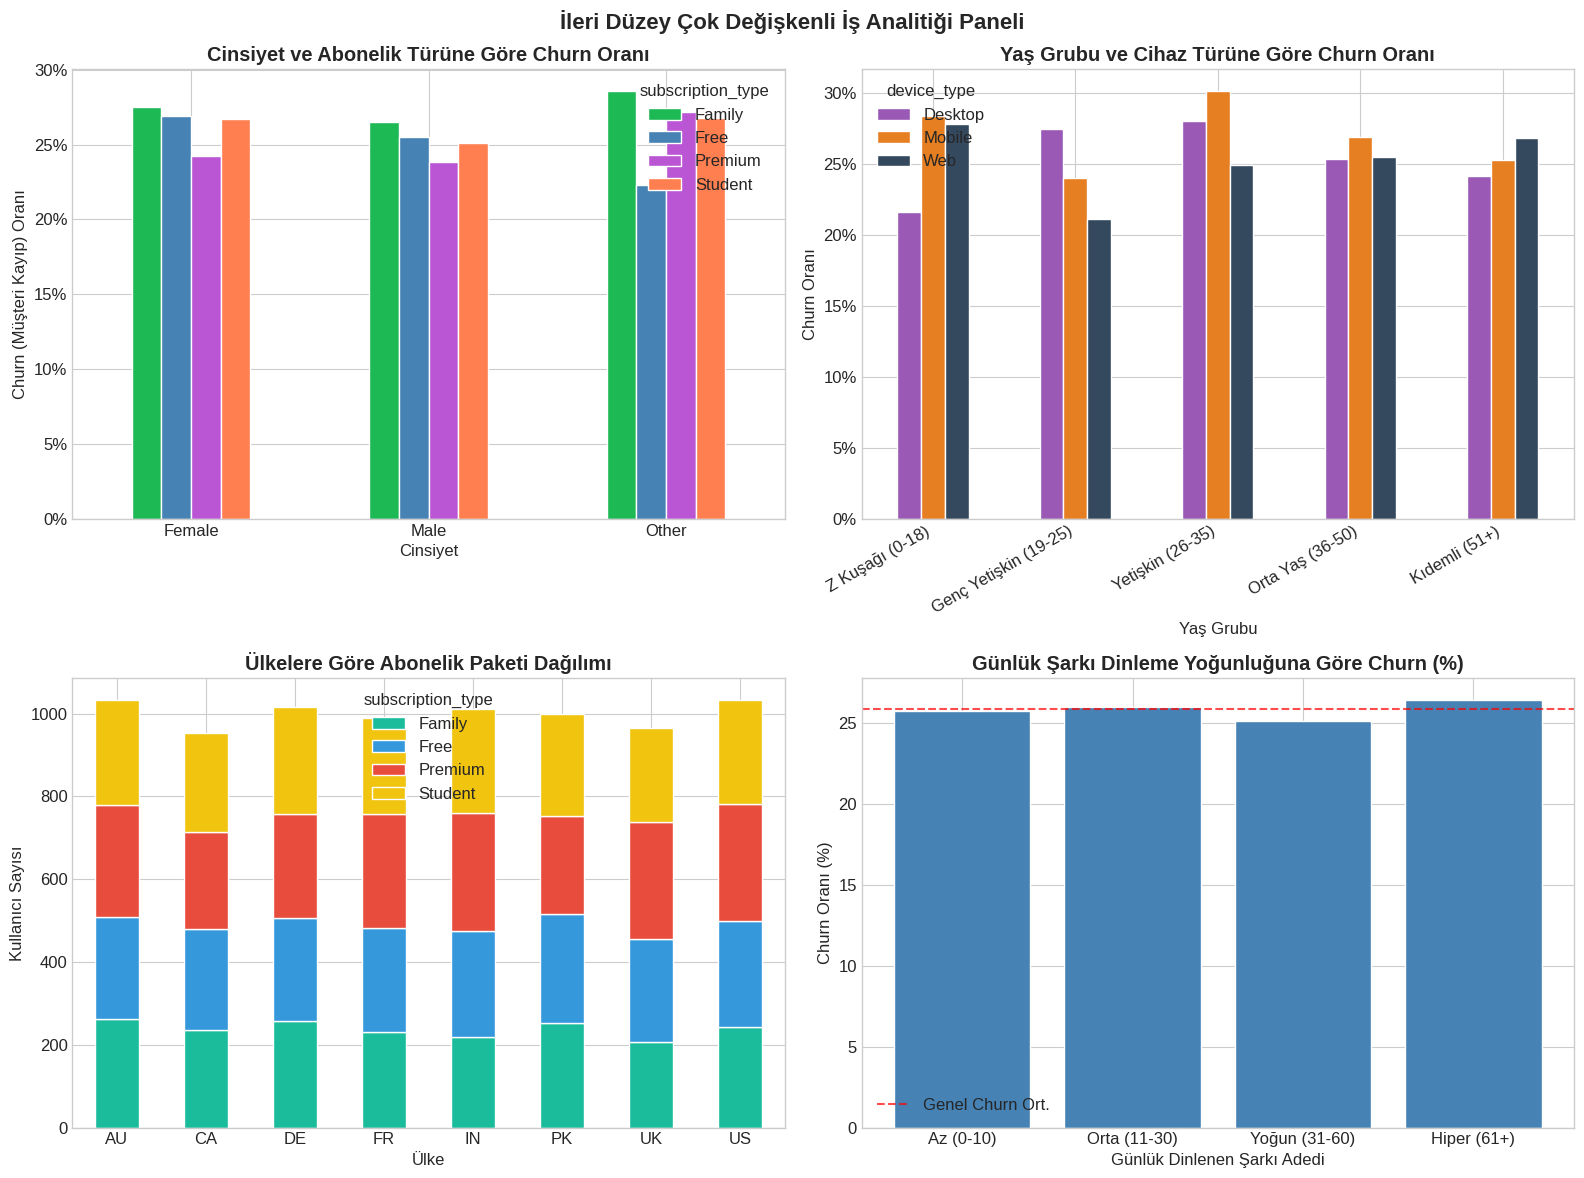

In [ ]:
# 4'lü büyük analiz panelini kuruyoruz
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1. GRAFİK: Cinsiyet ve Abonelik Türüne Göre Churn Oranı ---
pivot1 = df.groupby(['gender', 'subscription_type'])['is_churned'].mean().unstack()
pivot1.plot(kind='bar', ax=axes[0, 0], color=['#1DB954', '#4682B4', '#BA55D3', '#FF7F50'], edgecolor='white')
axes[0, 0].set_title('Cinsiyet ve Abonelik Türüne Göre Churn Oranı', fontweight='bold')
axes[0, 0].set_xlabel('Cinsiyet')
axes[0, 0].set_ylabel('Churn (Müşteri Kayıp) Oranı')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# --- 2. GRAFİK: Yaş Grubu (Binning) ve Cihaza Göre Churn ---
df['yas_grubu'] = pd.cut(df['age'],
                        bins=[0, 18, 25, 35, 50, 100],
                        labels=['Z Kuşağı (0-18)', 'Genç Yetişkin (19-25)', 'Yetişkin (26-35)', 'Orta Yaş (36-50)', 'Kıdemli (51+)'])

pivot2 = df.groupby(['yas_grubu', 'device_type'])['is_churned'].mean().unstack()
pivot2.plot(kind='bar', ax=axes[0, 1], color=['#9b59b6', '#e67e22', '#34495e'], edgecolor='white')
axes[0, 1].set_title('Yaş Grubu ve Cihaz Türüne Göre Churn Oranı', fontweight='bold')
axes[0, 1].set_xlabel('Yaş Grubu')
axes[0, 1].set_ylabel('Churn Oranı')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=30, ha='right')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# --- 3. GRAFİK: Ülkelere Göre Abonelik Sınıf Dağılımı (Stacked) ---
pivot3 = df.groupby(['country', 'subscription_type']).size().unstack(fill_value=0)
pivot3.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#1abc9c', '#3498db', '#e74c3c', '#f1c40f'], edgecolor='white')
axes[1, 0].set_title('Ülkelere Göre Abonelik Paketi Dağılımı', fontweight='bold')
axes[1, 0].set_xlabel('Ülke')
axes[1, 0].set_ylabel('Kullanıcı Sayısı')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

# --- 4. GRAFİK: Günlük Şarkı Dinleme Yoğunluğuna Göre Churn Analizi ---
# Şarkı dinleme sayılarını gruplayıp platform bağlılığına bakıyoruz
df['sarki_segmenti'] = pd.cut(df['songs_played_per_day'], bins=[0, 10, 30, 60, 100], labels=['Az (0-10)', 'Orta (11-30)', 'Yoğun (31-60)', 'Hiper (61+)'])
sarki_churn = df.groupby('sarki_segmenti', observed=False)['is_churned'].mean() * 100

axes[1, 1].bar(sarki_churn.index, sarki_churn.values, color='steelblue', edgecolor='white')
axes[1, 1].set_title('Günlük Şarkı Dinleme Yoğunluğuna Göre Churn (%)', fontweight='bold')
axes[1, 1].set_xlabel('Günlük Dinlenen Şarkı Adedi')
axes[1, 1].set_ylabel('Churn Oranı (%)')
axes[1, 1].axhline(df['is_churned'].mean()*100, color='red', linestyle='--', alpha=0.7, label='Genel Churn Ort.')
axes[1, 1].legend()

plt.suptitle('İleri Düzey Çok Değişkenli İş Analitiği Paneli', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

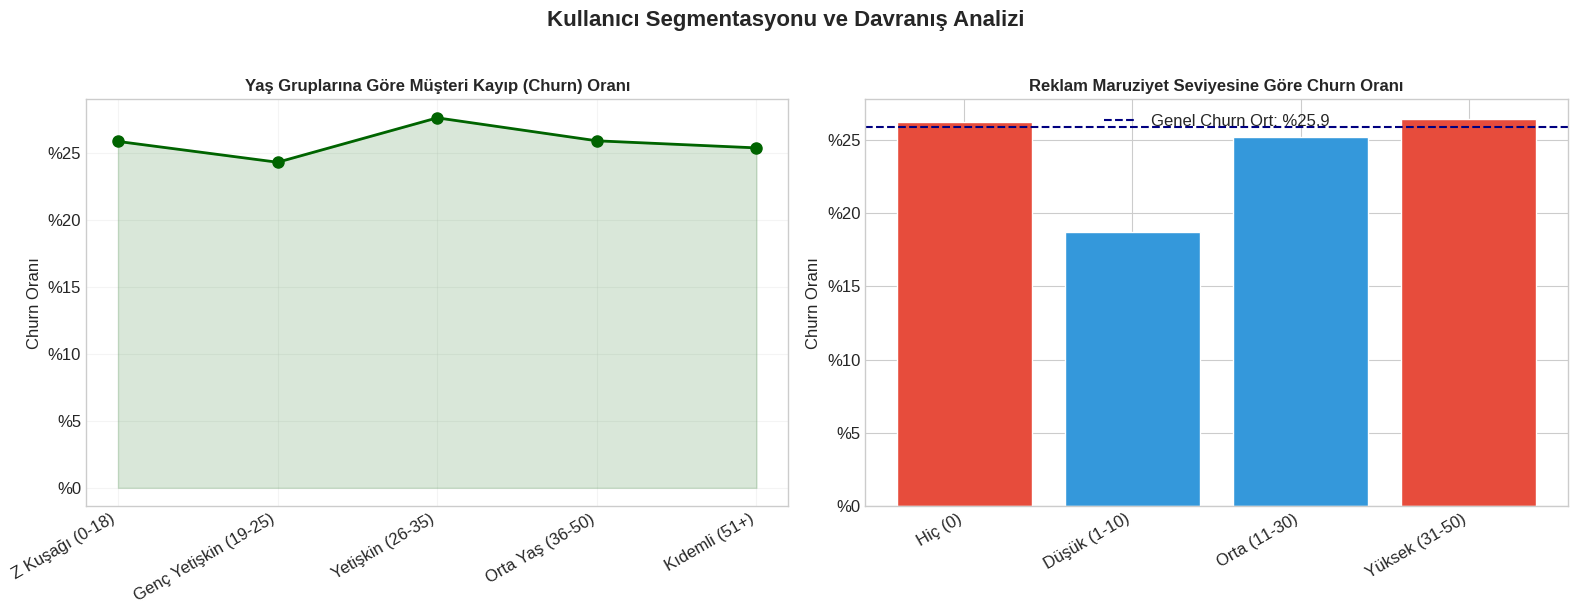

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi okuyoruz
df = pd.read_csv('spotify_churn_dataset.csv')

# Yaş gruplarını tanımlıyoruz (Hocanın pd.cut mantığı)
df['yas_grubu'] = pd.cut(df['age'],
                        bins=[0, 18, 25, 35, 50, 100],
                        labels=['Z Kuşağı (0-18)', 'Genç Yetişkin (19-25)', 'Yetişkin (26-35)', 'Orta Yaş (36-50)', 'Kıdemli (51+)'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol Grafik: Yaş Gruplarına Göre Ortalama Churn Oranı
yas_churn = df.groupby('yas_grubu', observed=False)['is_churned'].mean()
axes[0].plot(yas_churn.index, yas_churn.values, 'o-', color='darkgreen', linewidth=2, markersize=8)
axes[0].fill_between(yas_churn.index, yas_churn.values, alpha=0.15, color='darkgreen')
axes[0].set_title('Yaş Gruplarına Göre Müşteri Kayıp (Churn) Oranı', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Churn Oranı')
axes[0].set_xticklabels(yas_churn.index, rotation=30, ha='right')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'%{x*100:.0f}'))
axes[0].grid(True, alpha=0.2)

# Sağ Grafik: Haftalık Reklam İzleme Sayısına Göre Churn Oranları
# Reklam sayılarını gruplara bölüyoruz
df['reklam_segmenti'] = pd.cut(df['ads_listened_per_week'],
                               bins=[-1, 0, 10, 30, 50, 100],
                               labels=['Hiç (0)', 'Düşük (1-10)', 'Orta (11-30)', 'Yüksek (31-50)', 'Aşırı (51+)'])

reklam_churn = df.groupby('reklam_segmenti', observed=False)['is_churned'].mean()
# Genel ortalamanın üzerindekileri kırmızı, altındakileri mavi yapma (Hocanın bar renklendirme mantığı)
renkler_reklam = ['#3498db' if x < df['is_churned'].mean() else '#e74c3c' for x in reklam_churn.values]

axes[1].bar(reklam_churn.index, reklam_churn.values, color=renkler_reklam, edgecolor='white')
axes[1].axhline(df['is_churned'].mean(), color='navy', linestyle='--', linewidth=1.5, label=f'Genel Churn Ort: %{df["is_churned"].mean()*100:.1f}')
axes[1].set_title('Reklam Maruziyet Seviyesine Göre Churn Oranı', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Churn Oranı')
axes[1].set_xticklabels(reklam_churn.index, rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'%{x*100:.0f}'))
axes[1].legend()

plt.suptitle('Kullanıcı Segmentasyonu ve Davranış Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

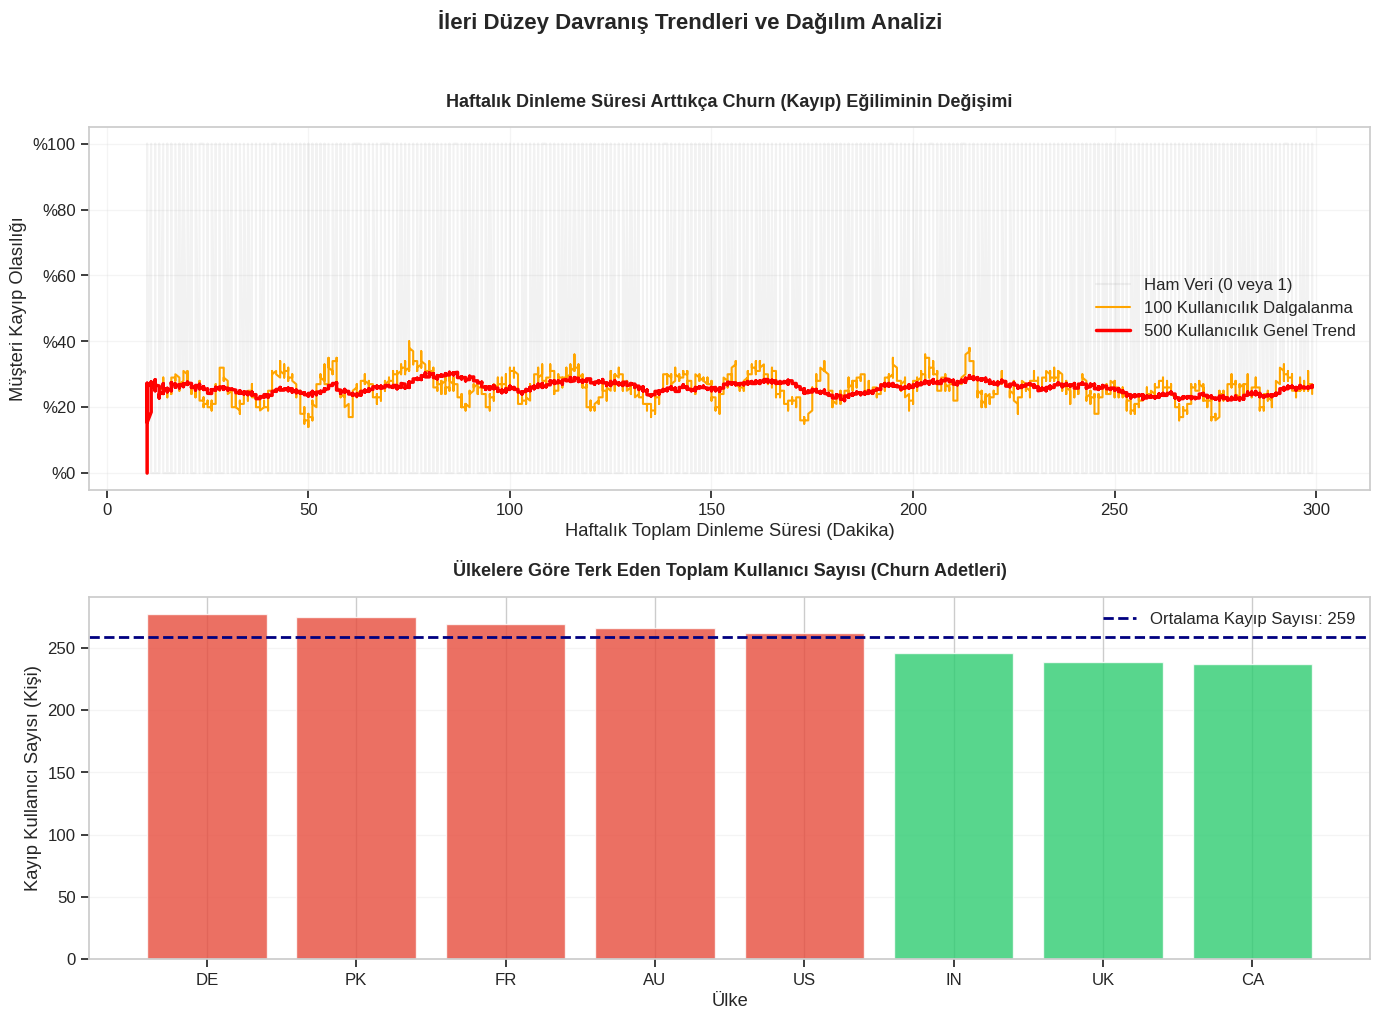

In [ ]:
# Veriyi dinleme süresine göre sıralıyoruz (Zaman serisi efekti yaratmak için)
df_sorted = df.sort_values(by='listening_time').reset_index(drop=True)

# Churn durumunun hareketli ortalamasını alıyoruz (Trendi görmek için)
df_sorted['churn_MA_100'] = df_sorted['is_churned'].rolling(window=100, min_periods=1).mean()
df_sorted['churn_MA_500'] = df_sorted['is_churned'].rolling(window=500, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Üst Grafik: Dinleme Süresi Arttıkça Churn Trendinin Değişimi (Rolling Mean İllüzyonu)
axes[0].plot(df_sorted['listening_time'], df_sorted['is_churned'], alpha=0.1, color='gray', label='Ham Veri (0 veya 1)')
axes[0].plot(df_sorted['listening_time'], df_sorted['churn_MA_100'], color='orange', linewidth=1.5, label='100 Kullanıcılık Dalgalanma')
axes[0].plot(df_sorted['listening_time'], df_sorted['churn_MA_500'], color='red', linewidth=2.5, label='500 Kullanıcılık Genel Trend')
axes[0].set_title('Haftalık Dinleme Süresi Arttıkça Churn (Kayıp) Eğiliminin Değişimi', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Haftalık Toplam Dinleme Süresi (Dakika)')
axes[0].set_ylabel('Müşteri Kayıp Olasılığı')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'%{x*100:.0f}'))
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Alt Grafik: Ülkelere Göre Toplam Kayıp Dağılımı (Hocanın Aylık Toplam Satış Mantığı)
ulke_churn_adet = df.groupby('country')['is_churned'].sum().sort_values(ascending=False)
colors_ulke = ['#e74c3c' if x > ulke_churn_adet.mean() else '#2ecc71' for x in ulke_churn_adet.values]

axes[1].bar(ulke_churn_adet.index, ulke_churn_adet.values, color=colors_ulke, edgecolor='white', alpha=0.8)
axes[1].axhline(ulke_churn_adet.mean(), color='navy', linestyle='--', linewidth=2, label=f'Ortalama Kayıp Sayısı: {ulke_churn_adet.mean():.0f}')
axes[1].set_title('Ülkelere Göre Terk Eden Toplam Kullanıcı Sayısı (Churn Adetleri)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Ülke')
axes[1].set_ylabel('Kayıp Kullanıcı Sayısı (Kişi)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.2)

plt.suptitle('İleri Düzey Davranış Trendleri ve Dağılım Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()